In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('kümeleme.csv')
print(f'Yüklendi: {df.shape}')

Yüklendi: (4418, 20)


In [3]:
STYLE_COLS = ['possession', 'xg_for', 'xg_against', 'shots', 'shots_on_target',
              'shot_accuracy', 'xg_diff']

df_style = df[STYLE_COLS].dropna()
print(f'Null olmayan satır: {len(df_style)}')


Null olmayan satır: 4417


In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(df_style)


In [5]:
inertias, silhouettes = [], []
K_RANGE = range(2, 8)

In [6]:
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    print(f'k={k}  inertia={km.inertia_:.0f}  silhouette={silhouette_score(X,labels):.4f}')

k=2  inertia=20839  silhouette=0.2748
k=3  inertia=17564  silhouette=0.2063
k=4  inertia=15398  silhouette=0.2033
k=5  inertia=13982  silhouette=0.1816
k=6  inertia=13047  silhouette=0.1760
k=7  inertia=12190  silhouette=0.1805


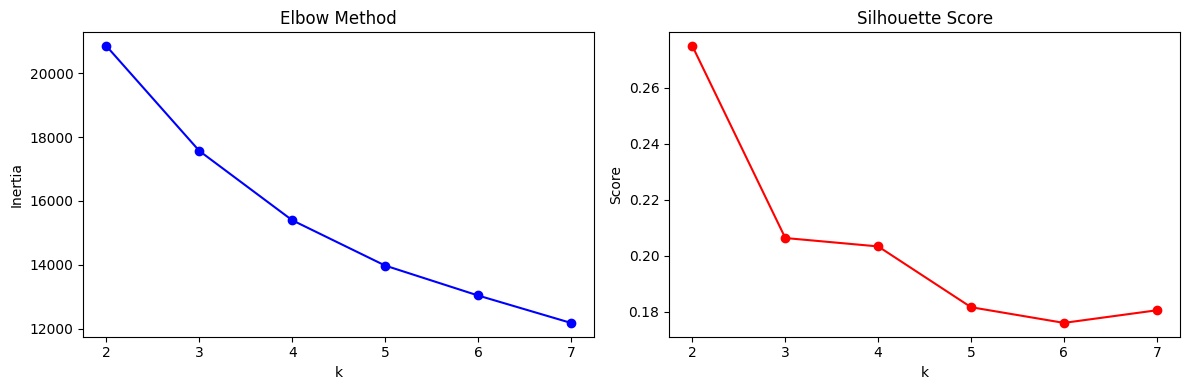

Grafik kaydedildi: elbow_silhouette.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(list(K_RANGE), silhouettes, 'ro-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k'); ax2.set_ylabel('Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print('Grafik kaydedildi: elbow_silhouette.png')
